<a href="https://colab.research.google.com/github/DanielYaari28/aipi590-telco-churn/blob/colby-GAM/colby_telcos_gam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
# !pip install pygam --quiet

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from pygam import LogisticGAM, s, l
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.stattools import durbin_watson

In [45]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [46]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [48]:
df.drop(columns=['customerID'], axis=1, inplace=True)

In [49]:
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

In [50]:
df['Partner'] = df['Partner'].map({'No': 0, 'Yes': 1})

In [51]:
df['Dependents'] = df['Dependents'].map({'No': 0, 'Yes': 1})

In [52]:
df['PhoneService'] = df['PhoneService'].map({'No': 0, 'Yes': 1})

In [53]:
df['PaperlessBilling'] = df['PaperlessBilling'].map({'No': 0, 'Yes': 1})

In [54]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [55]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,0,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [56]:
ohe_columns = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=ohe_columns, dtype=int)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   PaperlessBilling                         7043 non-null   int64  
 7   MonthlyCharges                           7043 non-null   float64
 8   TotalCharges                             7043 non-null   object 
 9   Churn                                    7043 non-null   int64  
 10  MultipleLines_No                         7043 no

In [58]:
mask = df['TotalCharges'] != ' '
df = df[mask]

In [59]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7032 non-null   int64  
 1   SeniorCitizen                            7032 non-null   int64  
 2   Partner                                  7032 non-null   int64  
 3   Dependents                               7032 non-null   int64  
 4   tenure                                   7032 non-null   int64  
 5   PhoneService                             7032 non-null   int64  
 6   PaperlessBilling                         7032 non-null   int64  
 7   MonthlyCharges                           7032 non-null   float64
 8   TotalCharges                             7032 non-null   float64
 9   Churn                                    7032 non-null   int64  
 10  MultipleLines_No                         7032 non-nul

In [61]:
y = df['Churn']

In [62]:
features_to_drop = [
    'MultipleLines_No',            # Drop ref
    'InternetService_No',          # Drop ref
    'OnlineSecurity_No',           # Drop ref
    'OnlineBackup_No',             # Drop ref
    'DeviceProtection_No',         # Drop ref
    'TechSupport_No',              # Drop ref
    'StreamingTV_No',              # Drop ref
    'StreamingMovies_No',          # Drop ref
    'Contract_Month-to-month',     # Drop ref
    'PaymentMethod_Mailed check',   # Drop ref
    'Churn'                        # Target
]

X = df.drop(columns=features_to_drop, errors='ignore', axis=1)

In [63]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7032 non-null   int64  
 1   SeniorCitizen                            7032 non-null   int64  
 2   Partner                                  7032 non-null   int64  
 3   Dependents                               7032 non-null   int64  
 4   tenure                                   7032 non-null   int64  
 5   PhoneService                             7032 non-null   int64  
 6   PaperlessBilling                         7032 non-null   int64  
 7   MonthlyCharges                           7032 non-null   float64
 8   TotalCharges                             7032 non-null   float64
 9   MultipleLines_No phone service           7032 non-null   int64  
 10  MultipleLines_Yes                        7032 non-nul

In [64]:
# Absence of Perfect Separation
for col in X.columns:
    if X[col].nunique() == 2:  # dummy/binary columns
        churn_rate = y.groupby(X[col]).mean()
        if (churn_rate == 0).any() or (churn_rate == 1).any():
            print(f"Possible perfect separation in {col}:\n{churn_rate}\n")

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

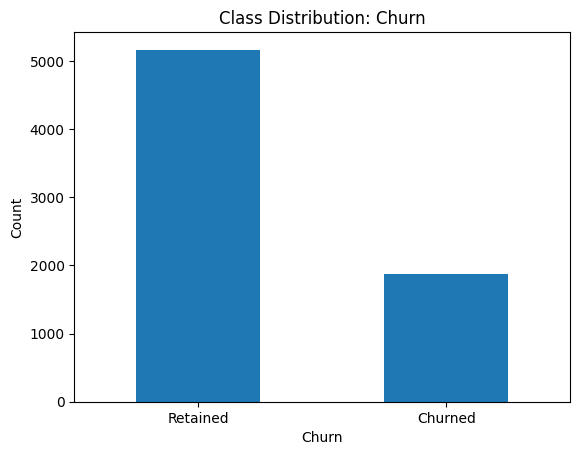

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [67]:
y.value_counts().plot(kind='bar')
plt.xticks([0, 1], ['Retained', 'Churned'], rotation=0)
plt.ylabel('Count')
plt.title('Class Distribution: Churn')
plt.show()

print(y.value_counts(normalize=True))

In [68]:
# undersample = RandomUnderSampler(random_state=42)
# X_train_bal, y_train_bal = undersample.fit_resample(X_train_scaled, y_train)

In [69]:
# y_train_bal.value_counts().plot(kind='bar')
# plt.xticks([0, 1], ['Retained', 'Churned'], rotation=0)
# plt.ylabel('Count')
# plt.title('Class Distribution: Churn')
# plt.show()

# print(y.value_counts(normalize=True))

In [70]:
# Initilize GAM
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

terms = None
for idx, col in enumerate(X.columns):
    term = s(idx) if col in continuous_cols else l(idx)
    terms = term if terms is None else (terms + term)

gam = LogisticGAM(terms)

# Find best smoothing parameters for each spline term
gam.gridsearch(X_train_scaled, y_train)

# for concurvity check (GAM version of multicollinearity)
pdep_values = {}
for term_idx, term in enumerate(gam.terms):
    if not term.isintercept and X.columns[term.feature] in continuous_cols:
        XX = gam.generate_X_grid(term=term_idx)
        pdep_values[X.columns[term.feature]] = gam.partial_dependence(term=term_idx, X=XX)

pdep_df = pd.DataFrame(pdep_values)

# Make predictions (probabilities for ROC-AUC / Log-Loss, binary labels for Accuracy)
y_pred_gam = gam.predict_proba(X_test_scaled)
y_pred_labels = gam.predict(X_test_scaled)

gam.summary()

100% (11 of 11) |########################| Elapsed Time: 0:00:03 Time:  0:00:03


LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     37.9194
Link Function:                        LogitLink Log Likelihood:                                 -2258.1377
Number of Samples:                         5625 AIC:                                             4592.1141
                                                AICc:                                            4592.6705
                                                UBRE:                                               2.8218
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.3067
Feature Function                  Lam

/tmp/ipykernel_3382/988657093.py:27: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


In [71]:
# Calculate Accuracy and ROC-AUC
acc_gam = accuracy_score(y_test, y_pred_labels)
roc_auc_gam = roc_auc_score(y_test, y_pred_gam)

print(f"GAM Accuracy: {acc_gam:.4f}, ROC-AUC: {roc_auc_gam:.4f}")

GAM Accuracy: 0.7939, ROC-AUC: 0.8365


In [72]:
print(classification_report(y_test, y_pred_labels, target_names=['Retained', 'Churned']))

              precision    recall  f1-score   support

    Retained       0.83      0.90      0.87      1033
     Churned       0.65      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [73]:
# show concurvity check
print(pdep_df.corr())

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000       -0.774038     -0.732718
MonthlyCharges -0.774038        1.000000      0.553007
TotalCharges   -0.732718        0.553007      1.000000


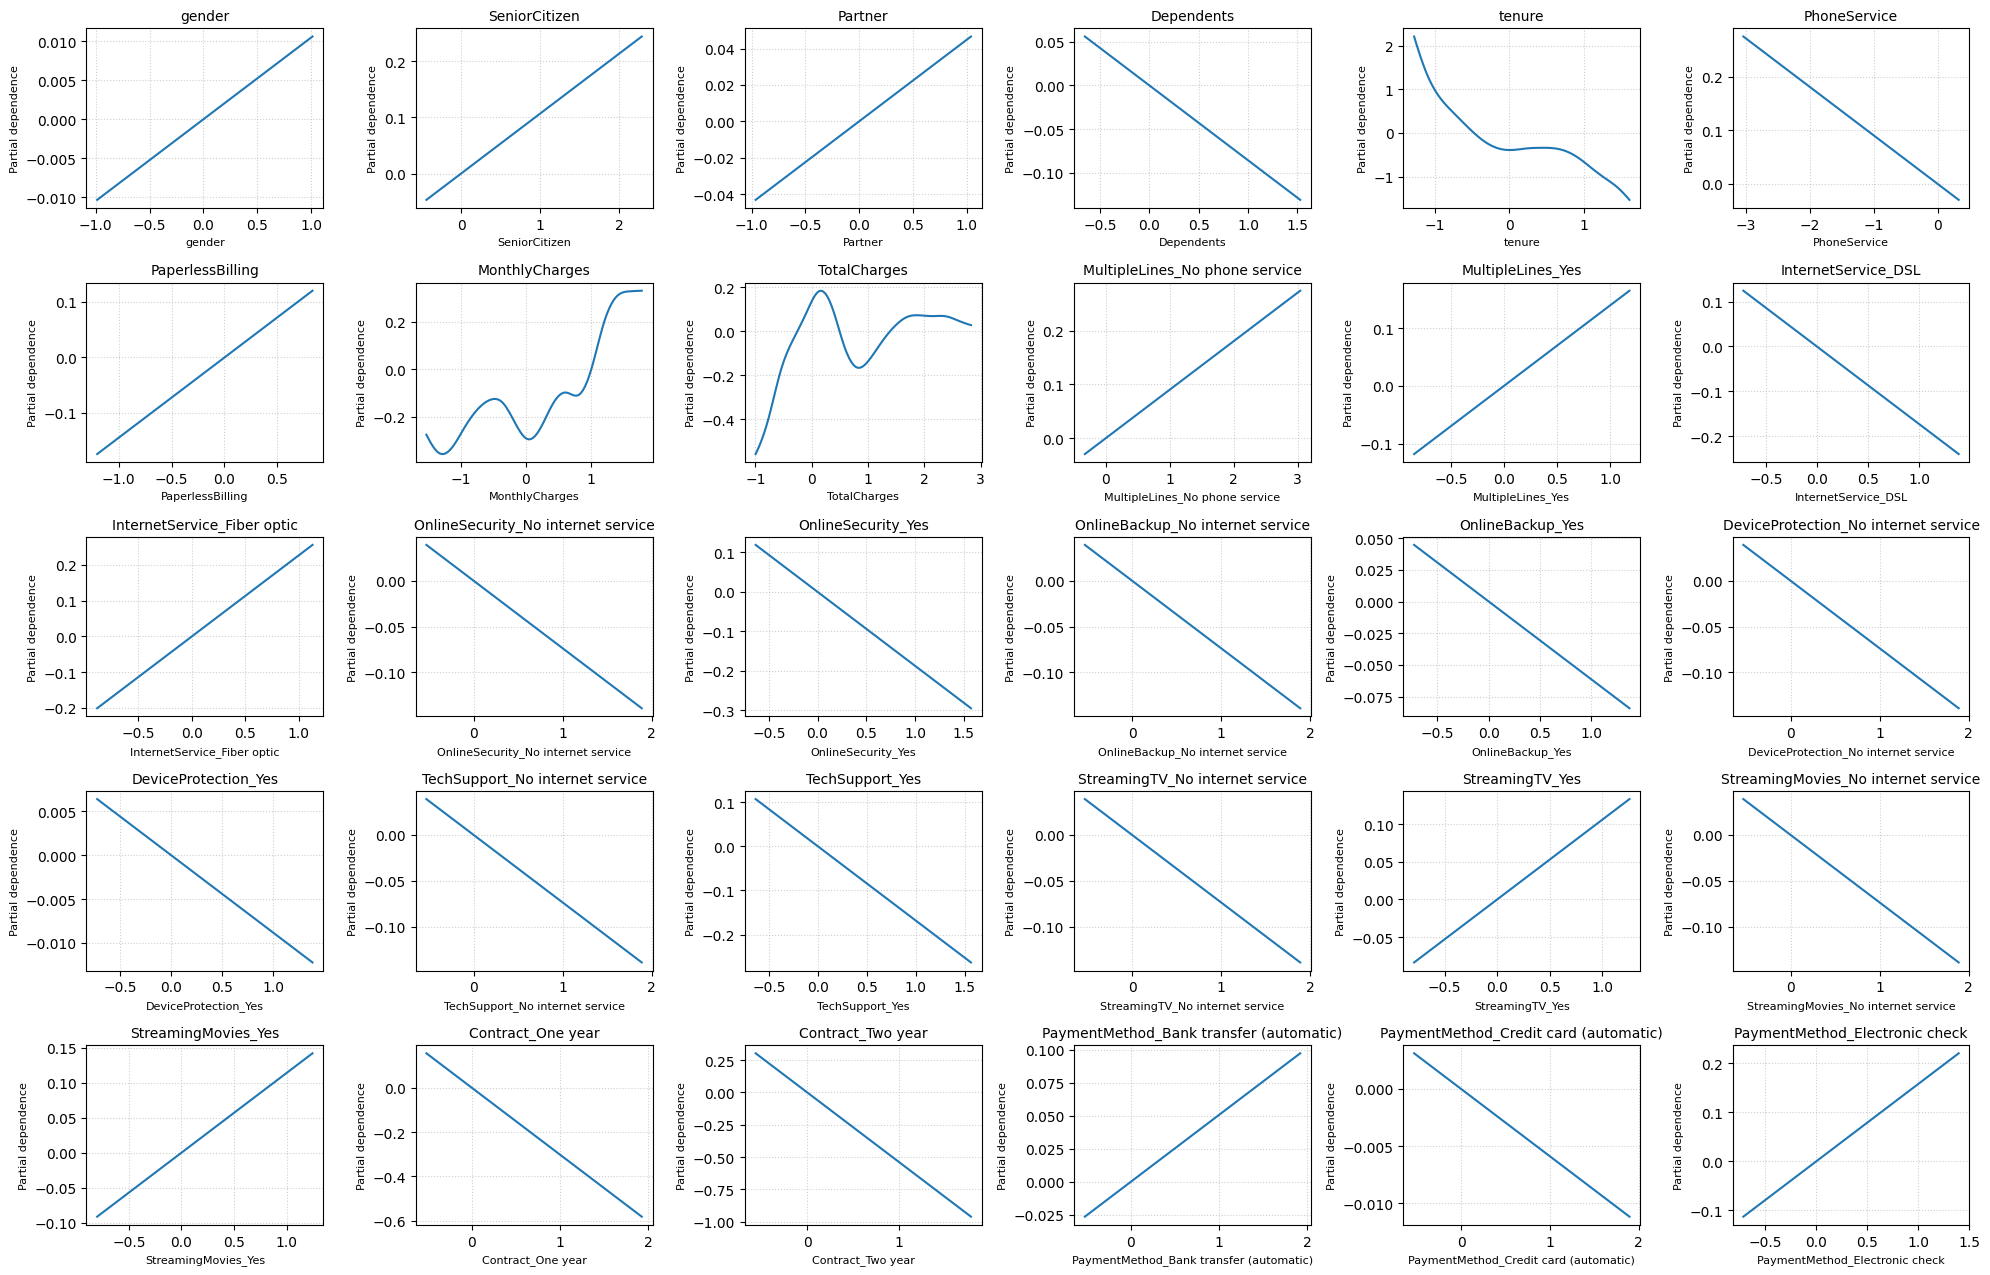

In [74]:
plt.figure(figsize=(20, 15))

# Filter out the intercept term to get valid plotting terms
valid_terms = [(i, term) for i, term in enumerate(gam.terms) if not term.isintercept]

for plot_idx, (term_idx, term) in enumerate(valid_terms, start=1):
    plt.subplot(6, 6, plot_idx)

    # Generate grid and calculate partial dependence
    XX = gam.generate_X_grid(term=term_idx)
    pdep = gam.partial_dependence(term=term_idx, X=XX)

    # Use X.columns instead of df.columns
    feature_name = X.columns[term.feature]

    plt.plot(XX[:, term.feature], pdep)
    plt.title(feature_name, fontsize=10)
    plt.xlabel(feature_name, fontsize=8)
    plt.ylabel('Partial dependence', fontsize=8)
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [78]:
y_prob = gam.predict_proba(X_test_scaled)
residuals = y_test - y_prob

In [76]:
dw_stat = durbin_watson(residuals)
print("=" * 45)
print(f"Durbin-Watson Statistic: {dw_stat:.4f}")
print("=" * 45)

Durbin-Watson Statistic: 1.9997


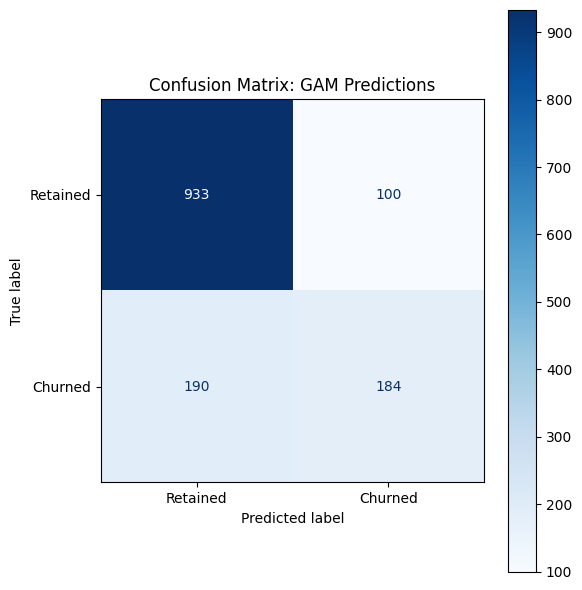

In [77]:
cm = confusion_matrix(y_test, y_pred_labels)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix: GAM Predictions')
plt.tight_layout()
plt.show()

## Assumption Findings:
1. Concurvity (multicollinearity for GAM): TotalCharges, tenure, and MonthlyCharges show high concurvity signals between each other.

2. Independence of Observations (Durbin-Watson): 1.7, which is between 1.5 and 2.5 so there is no concerning autocorrelation.

3. No Influential Outliers: linear tests don't work well for GAM, but examining the partial dependence graphs reveals no erratic behavior around the edges so there should be no influential outliers.

4. Absence of Perfection Separation: No binary columms were found to have only one target class, so this assumption was upheld.

5. Large Sample Size: There are over 7,000 observations and as many as possible were used in the training stage to meet the assumption.

## Limitation
GAMs need more data per feature to estimate spline curves effectively, so when working with unbalanced data there is a heavier tradeoff when applying sampling methods that reduce the training size. Oversampling could be a solution, but this introduces a risk of misrepresenting the population with fabricated observations.

## Smooth Effect Interpretation: tenure
The tenure partial dependence plot shows a steep decline in churn risk over the first few months but less of an impact for long tenures. The spline has captured the trend that extending already long tenures does not impact churn risk nearly as much as extending early customer tenure, which makes sense since new customers are much more volatile. The spline captures the changing dependency while a linear fit would underestimate early churn risk or overestimate long tenure churn risk.
